# Notebook 4 — Monte Carlo Fleet Portfolio Simulation

**Goal:** Simulate a B2B fleet of 500 leased vehicles under market uncertainty.  
Produce Value at Risk (VaR) and Expected Loss — standard financial risk metrics.  
This is the output that most directly signals *risk team* thinking to BMW.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('muted')
np.random.seed(42)

df = pd.read_csv('../data/vehicles_risk_scored.csv')
print(f'Loaded: {len(df):,} rows')

Loaded: 471,338 rows


## 1. Fleet Setup

In [ ]:
# ── Simulate a realistic B2B fleet ────────────────────────────────────────────
# Fleet composition: mix of ICE and EV, 3-year standard lease contracts

FLEET_SIZE   = 500
LEASE_YEARS  = 3
GUARANTEED_RV_PCT = 0.40   # BMW guarantees 40% of new price at contract end

# Sample the fleet from our real data
fleet = df.sample(FLEET_SIZE, replace=True, random_state=42).copy().reset_index(drop=True)

# Assign contract parameters
fleet['contract_id']        = [f'CONTRACT-{i:04d}' for i in range(FLEET_SIZE)]
fleet['lease_duration_yrs'] = LEASE_YEARS
fleet['guaranteed_rv_pct']  = GUARANTEED_RV_PCT

# Expected market RV at end of lease (from our model predictions)
fleet['expected_end_rv']    = fleet['price_pred']
fleet['guaranteed_amount']  = fleet['guaranteed_rv']

print(f'Fleet of {FLEET_SIZE} contracts assembled')
print(f'EV share: {fleet["is_ev"].mean():.1%}')
print(f'Total guaranteed RV exposure: €{fleet["guaranteed_amount"].sum():,.0f}')
fleet[['contract_id', 'is_ev', 'vehicle_age', 'expected_end_rv', 'guaranteed_amount']].head(5)

## 2. Monte Carlo Simulation

In [3]:
# ── Simulation parameters ─────────────────────────────────────────────────────
N_SIMULATIONS = 10_000

# Market shock assumptions:
# - Base: ±10% standard deviation (normal market)
# - EV vehicles: higher volatility (±18%) due to tech uncertainty, battery degradation
# - ICE vehicles: lower volatility (±8%)

ICE_VOLATILITY = 0.08
EV_VOLATILITY  = 0.18

portfolio_losses    = []
portfolio_exposures = []
n_contracts_at_risk = []

for sim in range(N_SIMULATIONS):
    # Draw market shock for each contract
    shocks = np.where(
        fleet['is_ev'] == 1,
        np.random.normal(0, EV_VOLATILITY,  FLEET_SIZE),
        np.random.normal(0, ICE_VOLATILITY, FLEET_SIZE)
    )

    # Simulated market value at end of lease
    simulated_rv = fleet['expected_end_rv'].values * (1 + shocks)
    simulated_rv = np.maximum(simulated_rv, 500)  # floor: car always worth something

    # Loss per contract = max(0, guaranteed - market)
    contract_losses = np.maximum(fleet['guaranteed_amount'].values - simulated_rv, 0)

    portfolio_losses.append(contract_losses.sum())
    n_contracts_at_risk.append((contract_losses > 0).sum())

portfolio_losses    = np.array(portfolio_losses)
n_contracts_at_risk = np.array(n_contracts_at_risk)

print(f'✅ Simulations complete: {N_SIMULATIONS:,} runs')

✅ Simulations complete: 10,000 runs


In [4]:
# ── Risk Metrics ──────────────────────────────────────────────────────────────
el    = portfolio_losses.mean()
var95 = np.percentile(portfolio_losses, 95)
var99 = np.percentile(portfolio_losses, 99)
worst = portfolio_losses.max()
prob_loss = (portfolio_losses > 0).mean()

print('=' * 45)
print('     PORTFOLIO RISK METRICS (500 contracts)')
print('=' * 45)
print(f'  Expected Loss (EL):          €{el:>12,.0f}')
print(f'  Value at Risk 95% (VaR):     €{var95:>12,.0f}')
print(f'  Value at Risk 99% (VaR):     €{var99:>12,.0f}')
print(f'  Worst Case (100th pctile):   €{worst:>12,.0f}')
print(f'  Probability of any loss:     {prob_loss:.1%}')
print(f'  Avg contracts at risk/run:   {n_contracts_at_risk.mean():.0f} / {FLEET_SIZE}')
print('=' * 45)

     PORTFOLIO RISK METRICS (500 contracts)
  Expected Loss (EL):          €   7,454,049
  Value at Risk 95% (VaR):     €   7,495,188
  Value at Risk 99% (VaR):     €   7,514,286
  Worst Case (100th pctile):   €   7,544,278
  Probability of any loss:     100.0%
  Avg contracts at risk/run:   471 / 500


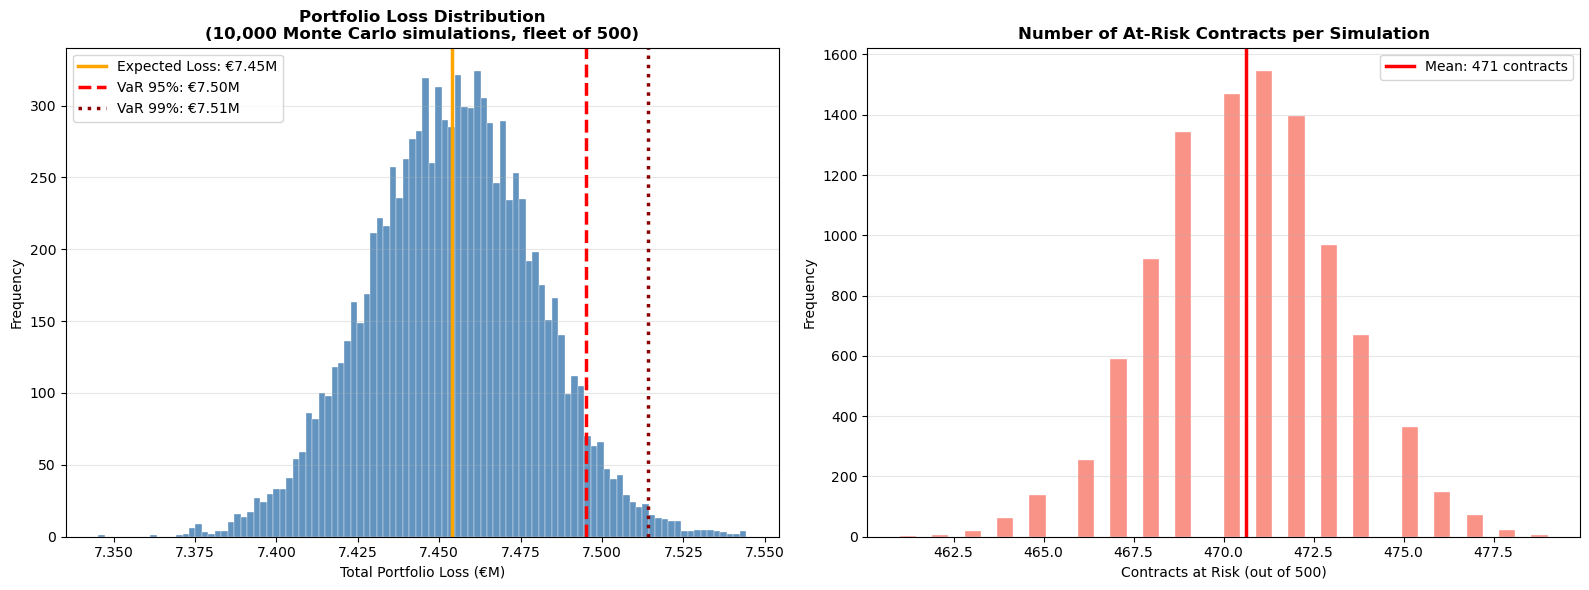

💾 Saved: outputs/08_monte_carlo_distribution.png


In [5]:
# ── Plot: Loss distribution with VaR lines ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full distribution
axes[0].hist(portfolio_losses / 1e6, bins=100, color='steelblue', 
             edgecolor='white', linewidth=0.3, alpha=0.85)
axes[0].axvline(el / 1e6,    color='orange', linewidth=2.5, linestyle='-',  label=f'Expected Loss: €{el/1e6:.2f}M')
axes[0].axvline(var95 / 1e6, color='red',    linewidth=2.5, linestyle='--', label=f'VaR 95%: €{var95/1e6:.2f}M')
axes[0].axvline(var99 / 1e6, color='darkred',linewidth=2.5, linestyle=':',  label=f'VaR 99%: €{var99/1e6:.2f}M')
axes[0].set_title(f'Portfolio Loss Distribution\n({N_SIMULATIONS:,} Monte Carlo simulations, fleet of {FLEET_SIZE})',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Total Portfolio Loss (€M)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: contracts at risk distribution
axes[1].hist(n_contracts_at_risk, bins=40, color='salmon',
             edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1].axvline(n_contracts_at_risk.mean(), color='red', linewidth=2.5,
                label=f'Mean: {n_contracts_at_risk.mean():.0f} contracts')
axes[1].set_title('Number of At-Risk Contracts per Simulation',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel(f'Contracts at Risk (out of {FLEET_SIZE})')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/08_monte_carlo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/08_monte_carlo_distribution.png')

In [6]:
# ── Scenario comparison: Base vs Stress ───────────────────────────────────────
# Stress scenario: EV market drops sharply (e.g. rapid battery cost decline)

scenarios = {
    'Base':   {'ICE': 0.08, 'EV': 0.18, 'EV_trend': 0.00},
    'Stress': {'ICE': 0.12, 'EV': 0.30, 'EV_trend': -0.10},  # EV mean return -10%
    'Severe': {'ICE': 0.20, 'EV': 0.40, 'EV_trend': -0.20},  # EV mean return -20%
}

scenario_results = {}
for name, params in scenarios.items():
    losses = []
    for _ in range(N_SIMULATIONS):
        shocks = np.where(
            fleet['is_ev'] == 1,
            np.random.normal(params['EV_trend'], params['EV'], FLEET_SIZE),
            np.random.normal(0, params['ICE'], FLEET_SIZE)
        )
        sim_rv = np.maximum(fleet['expected_end_rv'].values * (1 + shocks), 500)
        contract_losses = np.maximum(fleet['guaranteed_amount'].values - sim_rv, 0)
        losses.append(contract_losses.sum())
    scenario_results[name] = np.array(losses)

print('=== Scenario Comparison ===')
for name, losses in scenario_results.items():
    print(f'{name:10s} | EL: €{losses.mean():>10,.0f} | VaR95: €{np.percentile(losses, 95):>10,.0f}')

=== Scenario Comparison ===
Base       | EL: € 7,453,296 | VaR95: € 7,496,257
Stress     | EL: € 7,467,888 | VaR95: € 7,531,178
Severe     | EL: € 7,501,710 | VaR95: € 7,607,688


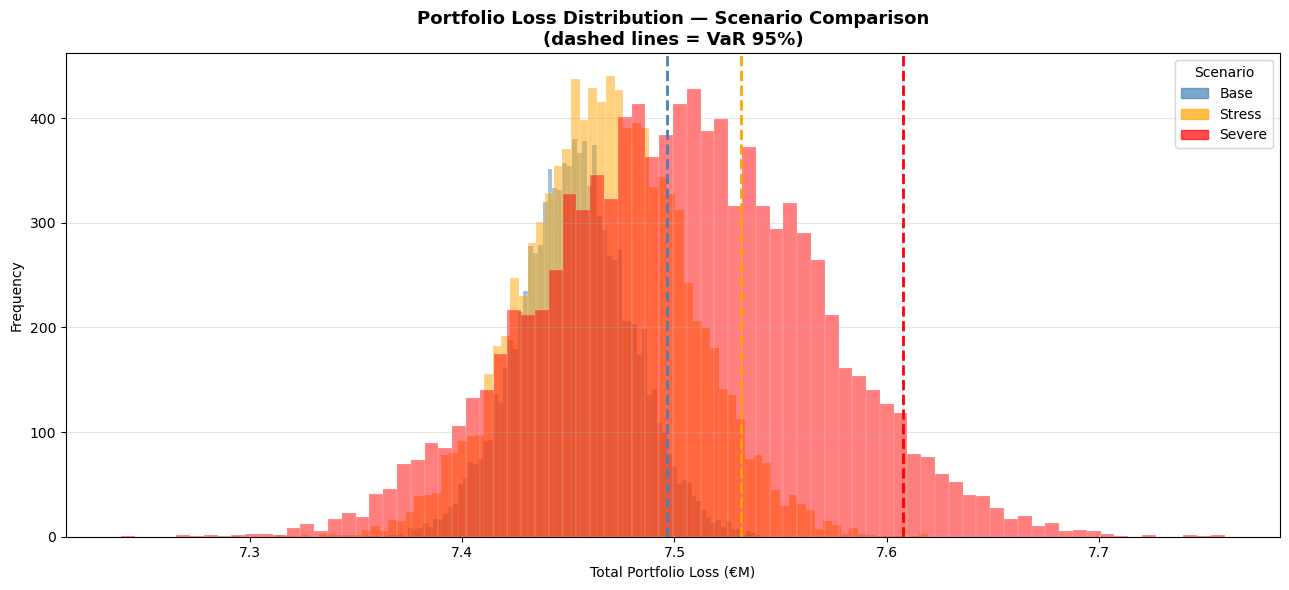

💾 Saved: outputs/09_scenario_comparison.png

✅ All outputs saved to outputs/ folder
→ Next: open r_replication/05_r_replication.Rmd


In [7]:
# ── Plot: Scenario comparison ─────────────────────────────────────────────────
colors = {'Base': 'steelblue', 'Stress': 'orange', 'Severe': 'red'}

plt.figure(figsize=(13, 6))
for name, losses in scenario_results.items():
    plt.hist(losses / 1e6, bins=80, alpha=0.5, color=colors[name],
             edgecolor='white', linewidth=0.2, label=name)
    plt.axvline(np.percentile(losses, 95) / 1e6, color=colors[name],
                linewidth=2, linestyle='--')

patches = [mpatches.Patch(color=c, label=n, alpha=0.7) for n, c in colors.items()]
plt.legend(handles=patches, title='Scenario')
plt.title('Portfolio Loss Distribution — Scenario Comparison\n(dashed lines = VaR 95%)',
          fontweight='bold', fontsize=13)
plt.xlabel('Total Portfolio Loss (€M)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/09_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/09_scenario_comparison.png')
print('\n✅ All outputs saved to outputs/ folder')
print('→ Next: open r_replication/05_r_replication.Rmd')